[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jinming99/learn-ml-by-building/blob/main/Lecture%202%20KNN/02-KNN.ipynb)
# Lecture 2: Framing Prediction Problems & k-Nearest Neighbors

## Learning Objectives

By the end of this lecture, you will:
- **Understand** how to frame real-world problems as ML tasks with inputs (X) and outputs (y)
- **Apply** k-NN to make predictions and understand the role of the k parameter
- **Analyze** the impact of distance metrics and feature scaling on predictions
- **Explore** the curse of dimensionality and its implications
- **Design** fair and effective matching systems with domain-specific constraints
- **Evaluate** trade-offs between different similarity measures



## Today's Journey

We'll solve a real problem: **Finding compatible ML project teammates** using k-Nearest Neighbors

We use fully fictional profiles to explore how matching works. No class roster is included.


# Part 1: The Problem - Finding Your ML Team

## Why Team Formation Matters

Good collaboration is crucial for ML projects. But how do we find compatible teammates?
- Similar interests? 
- Complementary skills?
- Compatible working styles?

Let's use ML to help!

### What we'll explore in our setup:
- Load fictional profiles with manually assigned features
- Examine the 8-dimensional feature space
- Understand how text responses became numbers

In [1]:
# @title Colab Setup
import sys
import os

if 'google.colab' in sys.modules:
    print("Detected Google Colab environment.")

    # 1. Clone the repository to access data and utilities
    if not os.path.exists('learn-ml-by-building'):
        print("Cloning repository...")
        !git clone https://github.com/jinming99/learn-ml-by-building.git

    # 2. Change directory to the specific lecture folder
    os.chdir('learn-ml-by-building/Lecture 2 KNN')
    print(f"Changed directory to: {os.getcwd()}")

    # 3. Install required packages
    print("Installing packages...")
    !pip install -q plotly matplotlib seaborn pandas numpy scikit-learn

    print("Colab setup complete!")
else:
    print("Running locally. Ensure you have run the setup instructions.")

Running locally. Ensure you have run the setup instructions.


In [2]:
# Dependencies are installed during environment setup.
import matplotlib
import seaborn


In [3]:
# Setup and imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import IFrame, display, HTML
import json
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

In [4]:
# Load the public fictional teaching fixture
with open('project-matchmaker/student_data_sample.json', 'r') as f:
    data = json.load(f)
    
# Extract components from the JSON structure    
students_list = data['students']
dimensions = data['dimensions']
dimension_descriptions = data['dimension_descriptions']
categorical_features = data['categorical_features']

# Preserve original feature values for every distance calculation
students = pd.DataFrame(students_list)

# Display basic statistics
n_students = len(students)
n_dimensions = len(dimensions)
n_categorical = len(categorical_features)

In [5]:
# Jitter is for drawing points only; distances always use students.
import hashlib

def apply_jitter(df, dims, jitter_amount=0.05):
    plotted = df.copy()
    for dim in dims:
        offsets = []
        for email in df['email']:
            seed = int(hashlib.md5(f"{email}_{dim}".encode()).hexdigest(), 16) % (2**32)
            offsets.append(np.random.default_rng(seed).uniform(-jitter_amount, jitter_amount))
        plotted[dim] = df[dim] + offsets
    return plotted

plot_students = apply_jitter(students, dimensions)
print("Plot jitter: ±0.05; original features retained for distances.")


Plot jitter: ±0.05; original features retained for distances.


In [6]:
from IPython.display import display
import pandas as pd

# Decide columns
numeric_cols = dimensions if 'dimensions' in locals() and len(dimensions) else [c for c in students.select_dtypes(include='number').columns]

# Handle categorical metadata (dict or list)
if isinstance(categorical_features, dict):
    cat_items = list(categorical_features.items())
    cat_cols = list(categorical_features.keys())
else:
    cat_items = [(c, {}) for c in categorical_features]
    cat_cols = list(categorical_features)

print(f"Fictional profiles: {len(students)}")
print(f"Numerical dimensions ({len(numeric_cols)}): {', '.join(numeric_cols)}")
print(f"Categorical features ({len(cat_cols)}): {', '.join(cat_cols)}")

# Pretty print categorical details
for key, meta in cat_items:
    name = meta.get('name', key)
    values = meta.get('values', None)
    if values is not None:
        print(f"  - {name} [{key}]: {len(values)} levels -> {', '.join(map(str, values))}")
    else:
        print(f"  - {name} [{key}]")

# Optional: sample original responses if you have that column
# original_text_col = 'original_response'
if 'original_text_col' in locals() and original_text_col in students.columns:
    print("Original responses (sample):")
    for i, txt in enumerate(students[original_text_col].dropna().astype(str).head(3), 1):
        print(f"  {i}. {txt[:200]}")

Fictional profiles: 10
Numerical dimensions (8): theory_implementation, research_industry, structured_exploratory, solo_collaborative, depth_breadth, plan_iterate, data_model, foundational_applied
Categorical features (6): team_status, main_interest, experience_level, problem_preference, collaboration_style, has_project_idea
  - Team Formation Status [team_status]: 4 levels -> solo, seeking_small, seeking_medium, seeking_large
  - Primary Interest Area [main_interest]: 7 levels -> nlp, computer_vision, healthcare, robotics, energy, cybersecurity, general
  - Experience Level [experience_level]: 3 levels -> beginner, intermediate, advanced
  - Problem Type Preference [problem_preference]: 3 levels -> structured, exploratory, both
  - Collaboration Style [collaboration_style]: 3 levels -> meetings, divided, flexible
  - Has Specific Project Idea [has_project_idea]: 2 levels -> True, False


### Data Overview:
- **Fictional profiles:** Check how many responses we have
- **Numerical dimensions:** 8 manually assigned features
- **Categorical features:** Team status, interests, experience level
- **Mock responses:** Written to illustrate the feature meanings

## Let's See It In Action First!

Before diving into the theory, let's experience k-NN on the fictional profiles.

### **Interactive Demo Features:**
- Real-time k-NN visualization with fictional profiles
- Adjustable k parameter to see immediate effects
- Multiple dimension pairs to explore different perspectives
- Color coding by categorical features

In [ ]:
import socket, subprocess, sys
from pathlib import Path
from IPython.display import HTML, display

REL_DIR = Path("project-matchmaker")
entry = "index.html"
assert (REL_DIR / entry).is_file(), f"Missing demo: {REL_DIR / entry}"

if 'google.colab' not in sys.modules:
    if 'demo_server' not in globals() or demo_server.poll() is not None:
        with socket.socket() as sock:
            sock.bind(("127.0.0.1", 0))
            PORT = sock.getsockname()[1]
        demo_server = subprocess.Popen(
            [sys.executable, "-m", "http.server", str(PORT), "--bind", "127.0.0.1",
             "--directory", str(REL_DIR.resolve())],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
        )
    display(HTML(f'<a href="http://127.0.0.1:{PORT}/{entry}" target="_blank">Open fictional-profile demo</a>'))
else:
    print("Run locally for the interactive HTML demo; the plots below work in Colab.")



### **Key Observations from the Demo:**

After experimenting with the demo, you should notice:
- **Proximity = Similarity**: Students closer in the visualization have more similar preferences
- **K's Impact**: Smaller K → more specific matches, larger K → more general consensus
- **Dimension Dependency**: Your "neighbors" completely change based on which 2 of 8 dimensions you visualize
- **Clustering Patterns**: Natural groups form based on interests and working styles


# Part 2: Understanding the Data

## From Surveys to Numbers

These mock responses and feature values were authored for teaching. In an application, NLP could map survey responses to features.

### **What this code reveals:**
- How qualitative survey responses become quantitative features
- The meaning of each dimension on a -1 to +1 scale
- Visual representation of where a student falls on each spectrum

In [8]:
import matplotlib.pyplot as plt
import textwrap

def visualize_student_profile(student_idx=0,
                              base_font=12,        # overall text
                              title_font=13,       # per-row title
                              anchor_font=11,      # left/right labels
                              right_text_font=11,  # right panel text
                              suptitle_font=16,    # top title
                              marker_size=9,
                              bar_height=0.36,
                              wrap_width=64,
                              dpi=150):
    sample = students.iloc[student_idx]
    n_dims = len(dimensions)

    fig = plt.figure(figsize=(13, 1.25 * n_dims + 2), dpi=dpi)
    gs = fig.add_gridspec(nrows=n_dims, ncols=2, width_ratios=[2.4, 1.8],
                          wspace=0.38, hspace=0.62)

    for i, dim in enumerate(dimensions):
        ax = fig.add_subplot(gs[i, 0])
        value = float(sample[dim])

        ax.barh(0, 2, left=-1, height=bar_height, color='lightgray', alpha=0.3)
        color = 'green' if value > 0 else 'red'
        ax.barh(0, value, height=bar_height, color=color, alpha=0.85)
        ax.plot(value, 0, 'o', color='black', markersize=marker_size)

        ax.set_xlim(-1, 1)
        ax.set_ylim(-0.5, 0.5)
        ax.set_yticks([])
        ax.axvline(0, color='black', linestyle='--', alpha=0.3)
        ax.tick_params(labelsize=base_font)

        desc = dimension_descriptions[dim]
        if '→' in desc:
            left_label, right_label = desc.split('→')
        elif '->' in desc:
            left_label, right_label = desc.split('->')
        else:
            left_label, right_label = desc, ''
        left_label = left_label.replace('←', '').strip()
        right_label = right_label.strip()

        ax.text(-0.95, -0.38, left_label, fontsize=anchor_font, ha='left')
        ax.text(0.95, -0.38, right_label, fontsize=anchor_font, ha='right')
        ax.set_title(f"{dim.replace('_', ' ').title()}: {value:+.2f}",
                     fontsize=title_font, loc='left')

        for side in ('top', 'right', 'bottom'):
            ax.spines[side].set_visible(False)

    ax_text = fig.add_subplot(gs[:, 1])
    ax_text.axis('off')

    lines = []
    lines.append(f"{sample.get('name','(unknown)')}  •  {sample.get('email','')}")
    lines.append(f"Interest: {sample.get('main_interest','')}")
    contact = sample.get('contact', '')
    if contact:
        lines.append(f"Contact: {contact}")
    lines.append("")
    lines.append("Mock responses:")

    orig = sample.get('original_responses', {})
    ordered_keys = [
        'application_area', 'team_needed', 'project_approach',
        'experience', 'problem_type', 'project_ideas', 'collaboration_style'
    ]
    label_map = {
        'application_area': 'Application Area',
        'team_needed': 'Team Needed',
        'project_approach': 'Project Approach',
        'experience': 'Experience',
        'problem_type': 'Problem Type',
        'project_ideas': 'Project Ideas',
        'collaboration_style': 'Collaboration Style',
    }
    for k in ordered_keys:
        if isinstance(orig, dict) and k in orig:
            lines.append(f"{label_map.get(k, k.replace('_',' ').title())}:")
            for wrapped in textwrap.wrap(str(orig[k]), width=wrap_width):
                lines.append(f"  {wrapped}")
            lines.append("")

    ax_text.text(0, 1, "\n".join(lines), va='top', ha='left', fontsize=right_text_font)

    fig.suptitle(f"Profile: {sample.get('name','(unknown)')} — {sample.get('main_interest','')}",
                 fontsize=suptitle_font, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

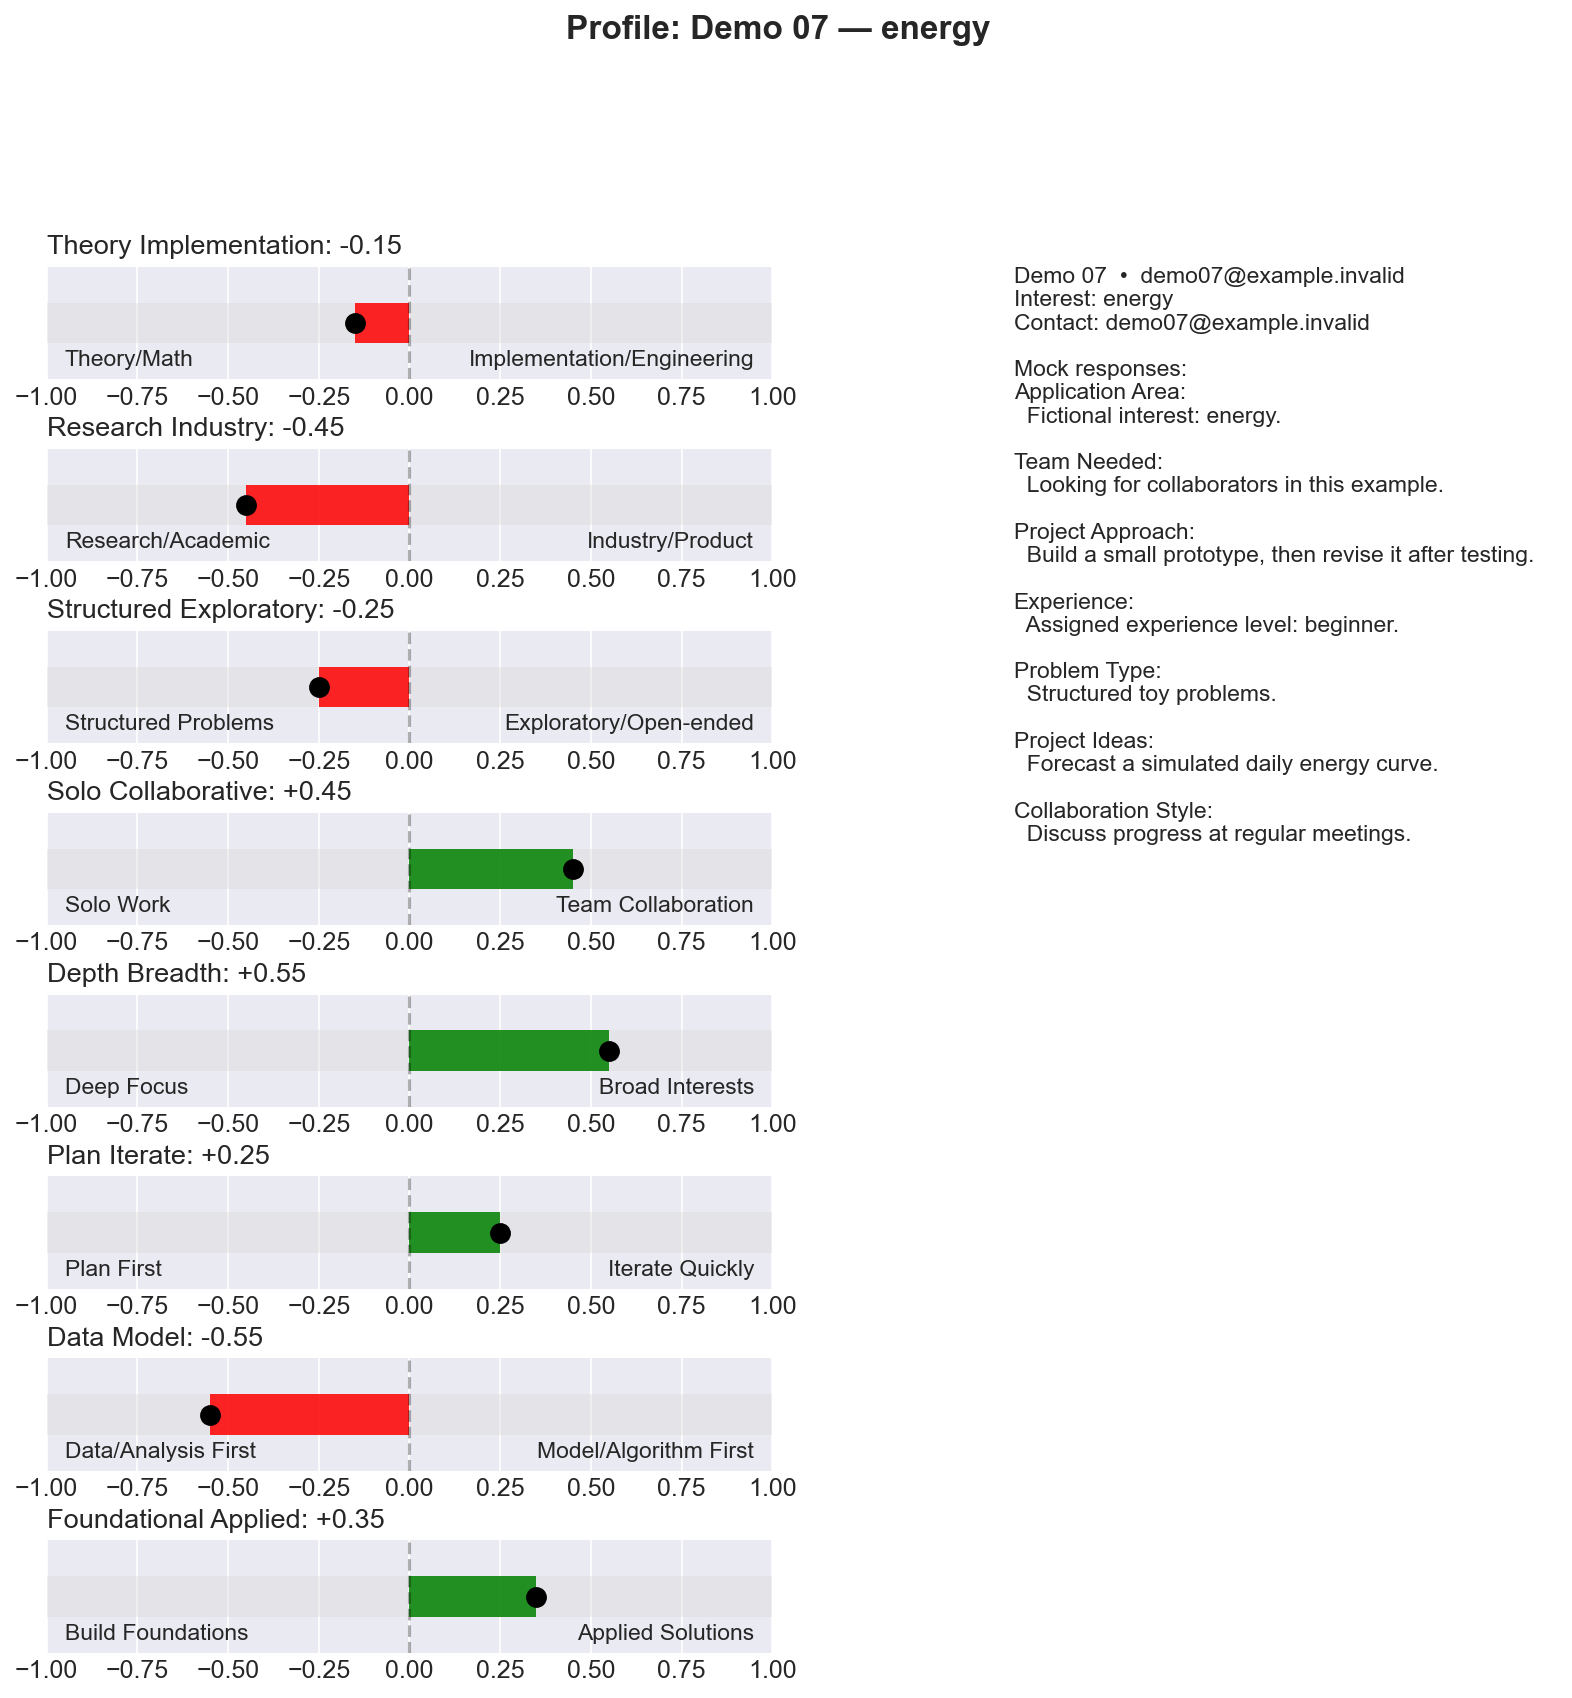

In [9]:
visualize_student_profile(np.random.randint(0, len(students)))

### Profile Interpretation:
- **Negative values** (left side): Theory, research, structured, solo work preferences
- **Positive values** (right side): Implementation, industry, exploratory, collaborative preferences  
- **Near zero**: Balanced or neutral on that dimension
- **Extreme values** (±0.8+): Strong preferences that heavily influence matching


## The Feature Space

### **Distribution Analysis Goals:**
- Understand the diversity of student preferences
- Identify potential clustering or gaps
- Check for feature scaling issues
- Detect any extraction biases

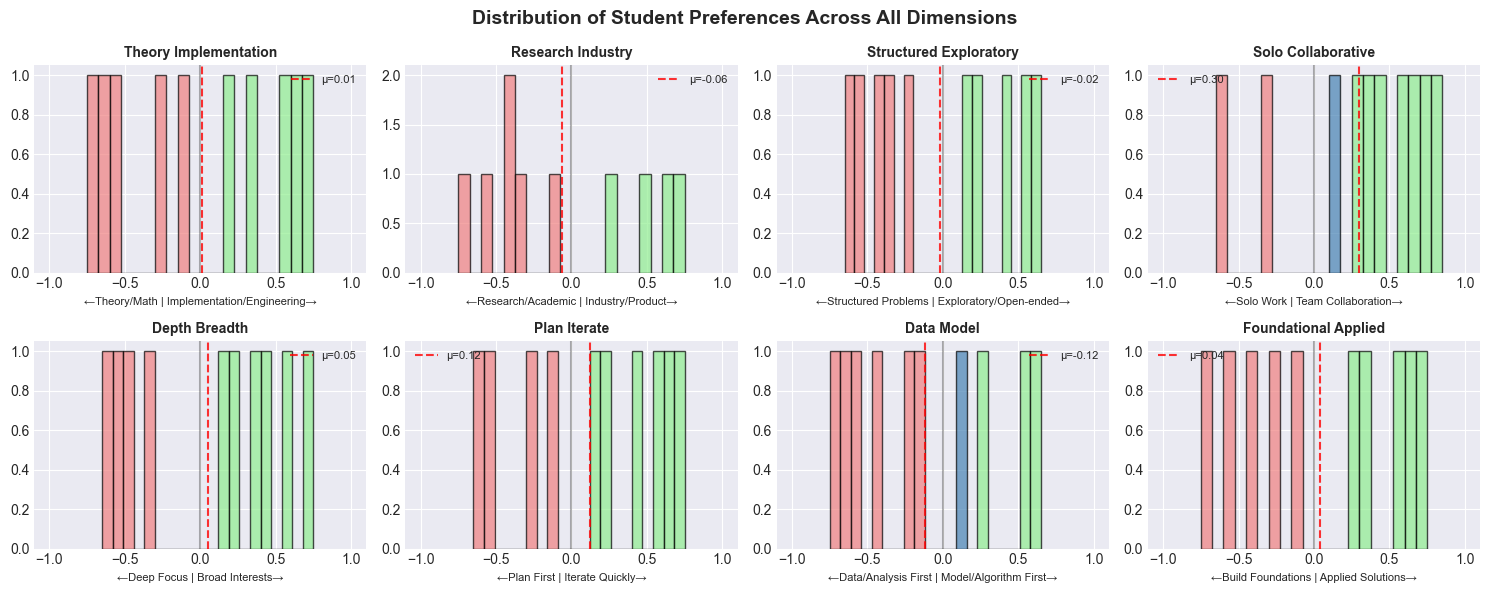

In [10]:
def analyze_feature_distributions():
    """
    Analyze and visualize the distribution of all numerical features
    """
    # Create figure with subplots for each dimension
    fig, axes = plt.subplots(2, 4, figsize=(15, 6))
    axes = axes.flatten()
    
    # Store statistics for later analysis
    feature_stats = {}
    
    for idx, dim in enumerate(dimensions):
        ax = axes[idx]
        values = students[dim].values
        
        # Calculate statistics
        feature_stats[dim] = {
            'mean': values.mean(),
            'std': values.std(),
            'min': values.min(),
            'max': values.max(),
            'skew': ((values - values.mean())**3).mean() / values.std()**3
        }
        
        # Plot distribution
        n, bins, patches = ax.hist(values, bins=20, alpha=0.7, 
                                   color='steelblue', edgecolor='black')
        
        # Color bars by position (red for negative, green for positive)
        for i, patch in enumerate(patches):
            if bins[i] < -0.1:
                patch.set_facecolor('lightcoral')
            elif bins[i] > 0.1:
                patch.set_facecolor('lightgreen')
        
        # Add mean line
        ax.axvline(values.mean(), color='red', linestyle='--', 
                  alpha=0.8, label=f'μ={values.mean():.2f}')
        ax.axvline(0, color='black', linestyle='-', alpha=0.3)
        
        # Labels and formatting
        description = dimension_descriptions[dim]
        ax.set_xlabel(f"←{description.split('→')[0].replace('←', '').strip()} | "
                     f"{description.split('→')[1].strip()}→", fontsize=8)
        ax.set_title(dim.replace('_', ' ').title(), fontsize=10, fontweight='bold')
        ax.set_xlim(-1.1, 1.1)
        ax.legend(fontsize=8)
    
    plt.suptitle("Distribution of Student Preferences Across All Dimensions", 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return feature_stats

# Analyze distributions
feature_stats = analyze_feature_distributions()

### **Distribution Insights:**
- **Balanced dimensions**: Mean near 0 describes this sample; it does not validate feature extraction
- **Skewed dimensions**: May indicate biases in survey questions or extraction
- **Bimodal patterns**: Suggest natural groupings in the class
- **Range coverage**: Full use of [-1, 1] indicates good feature scaling


# Part 3: The k-NN Algorithm

## The Beautiful Simplicity of k-NN

### Core k-NN Principle:
> "You are similar to your neighbors"

**No training phase needed!** k-NN is a "lazy learner" that:
1. Stores all training data
2. Makes predictions based on similarity at query time
3. Uses local patterns rather than global models

In [11]:
def knn_from_scratch(query_point, data_points, dimensions_to_use, k=3):
    """
    Implement k-NN from scratch to understand the algorithm
    
    Parameters:
    -----------
    query_point : array-like
        The point we want to find neighbors for
    data_points : DataFrame
        All available data points
    dimensions_to_use : list
        Which dimensions to use for distance calculation
    k : int
        Number of neighbors to find
    
    Returns:
    --------
    list of tuples: (index, distance, student_data)
    """
    distances = []
    
    # Step 1: Calculate distance to every other point
    for idx, point in data_points.iterrows():
        # Extract features for distance calculation
        point_features = point[dimensions_to_use].values
        
        # Euclidean distance calculation
        # d = sqrt(sum((x_i - y_i)^2))
        squared_diffs = (query_point - point_features) ** 2
        euclidean_dist = np.sqrt(squared_diffs.sum())
        
        # Store index, distance, and full student data
        distances.append((idx, euclidean_dist, point))
    
    # Step 2: Sort by distance (ascending - nearest first)
    distances.sort(key=lambda x: x[1])
    
    # Step 3: Return k nearest neighbors
    return distances[:k]



In [12]:
import pandas as pd

# Demonstrate with fictional profiles
# Let's find neighbors using just 2 dimensions for visualization
dims_to_use = ['theory_implementation', 'research_industry']

# Create a query point (implementation-focused, research-oriented)
query = np.array([1, -1])

# Find K nearest neighbors
neighbors = knn_from_scratch(query, students, dims_to_use, k=5)

# Pretty print k-NN results
cols = ['rank', 'idx', 'name', 'email', 'main_interest', 'distance'] + dims_to_use
rows = []
for r, (idx, dist, stu) in enumerate(neighbors, 1):
    rows.append([
        r,
        idx,
        stu.get('name', ''),
        stu.get('email', ''),
        stu.get('main_interest', ''),
        round(float(dist), 3),
        *[round(float(stu[d]), 3) for d in dims_to_use]
    ])

res_df = pd.DataFrame(rows, columns=cols)
print(f"k-NN results (k={len(neighbors)}, dims={dims_to_use}):")
display(res_df)

k-NN results (k=5, dims=['theory_implementation', 'research_industry']):


,rank,idx,name,email,main_interest,distance,theory_implementation,research_industry
0,1,2,Demo 03,demo03@example.invalid,robotics,0.886,0.15,-0.75
1,2,7,Demo 08,demo08@example.invalid,robotics,0.886,0.75,-0.15
2,3,6,Demo 07,demo07@example.invalid,energy,1.275,-0.15,-0.45
3,4,3,Demo 04,demo04@example.invalid,healthcare,1.329,-0.25,-0.55
4,5,1,Demo 02,demo02@example.invalid,computer_vision,1.492,0.65,0.45


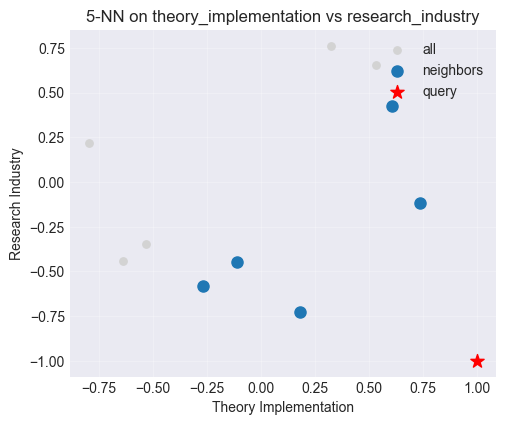

In [13]:
# 2D scatter (only if dims_to_use has length 2)
if len(dims_to_use) == 2:
    import matplotlib.pyplot as plt

    x, y = dims_to_use
    n_idx = [i for i, _, _ in neighbors]

    plt.figure(figsize=(5.5, 4.5))
    plt.scatter(plot_students[x], plot_students[y], s=28, c='lightgray', label='all')
    plt.scatter(plot_students.loc[n_idx, x], plot_students.loc[n_idx, y], s=64, c='tab:blue', label='neighbors')
    plt.scatter(query[0], query[1], s=100, c='red', marker='*', label='query')

    plt.xlabel(x.replace('_', ' ').title())
    plt.ylabel(y.replace('_', ' ').title())
    plt.title(f"{len(neighbors)}-NN on {x} vs {y}")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()


### **Algorithm Analysis:**
- **Time Complexity**: O(n·d + n log n) here: calculate distances, then sort
- **Space Complexity**: O(n·d) to store all data
- **No Training Time**: O(1) - just store the data!
- **Query Time**: Distance calculation is linear; this implementation also sorts all candidates


## Visualizing k-NN Decision Process

### **Visualization Goals:**
- Show how decision boundaries change with K
- Illustrate the bias-variance tradeoff
- Demonstrate overfitting (K=1) vs underfitting (large K)

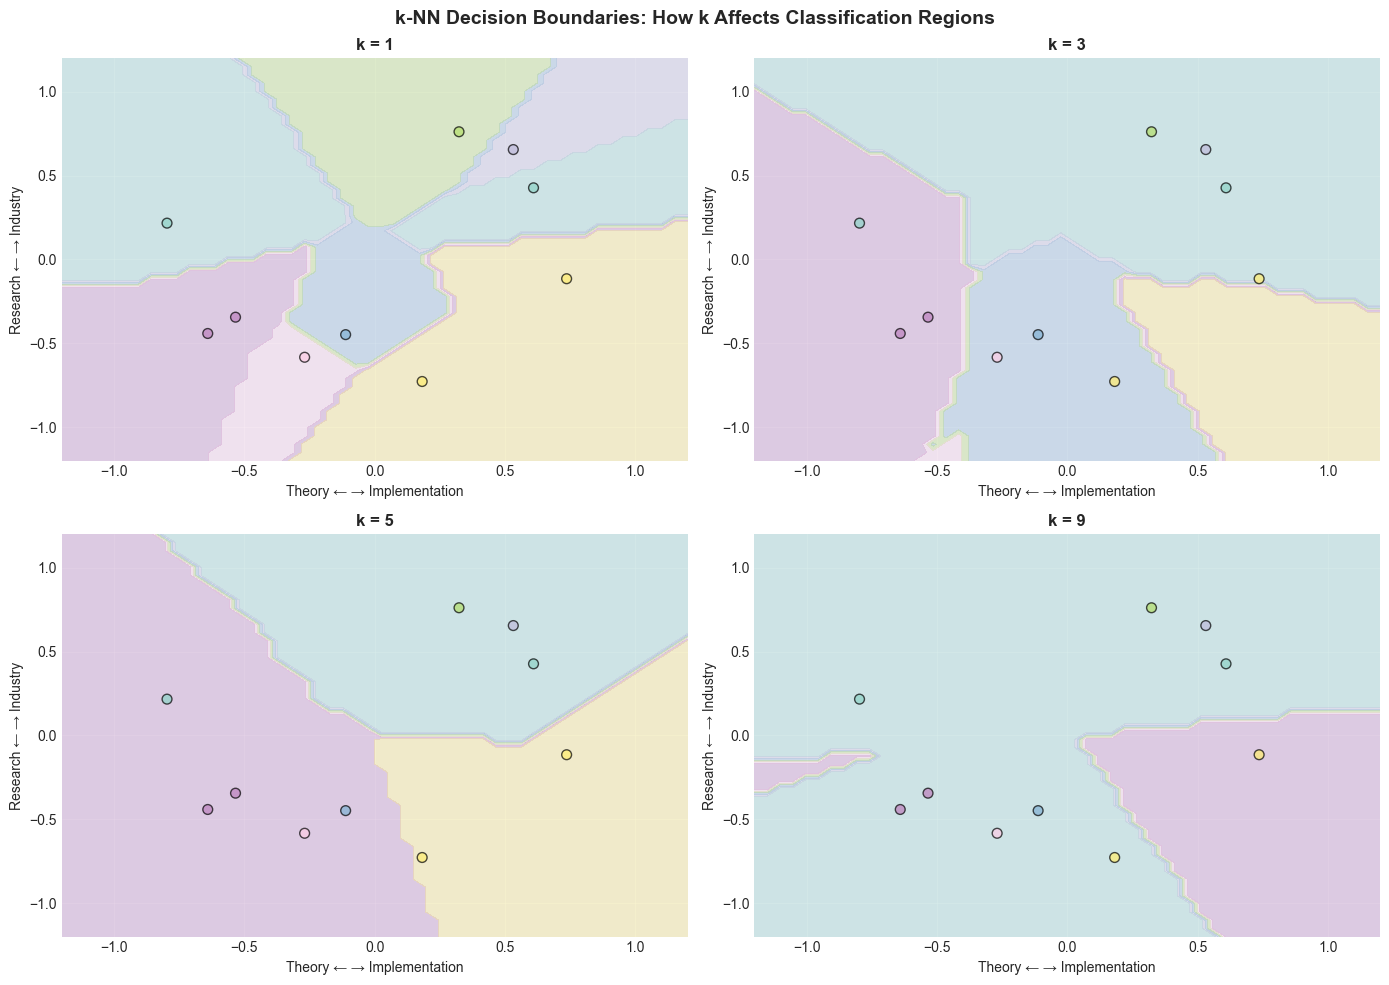

In [14]:
def visualize_knn_decision_boundaries(k_values=[1, 3, 5, 9]):
    """
    Create decision boundary visualizations for different k values
    
    This shows how the algorithm partitions the feature space
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    # Use two dimensions for visualization
    x_dim = 'theory_implementation'
    y_dim = 'research_industry'
    
    # Create mesh grid for decision boundary
    x_min, x_max = -1.2, 1.2
    y_min, y_max = -1.2, 1.2
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                        np.linspace(y_min, y_max, 50))
    
    # Prepare data for sklearn KNN
    X = students[[x_dim, y_dim]].values
    
    # Use main_interest as the classification target
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(students['main_interest'])
    
    for idx, k in enumerate(k_values):
        ax = axes[idx]
        
        # Train k-NN classifier
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X, y)
        
        # Predict for each point in mesh
        Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        
        # Plot decision boundaries
        ax.contourf(xx, yy, Z, levels=np.arange(len(label_encoder.classes_) + 1) - 0.5,
                    vmin=-0.5, vmax=len(label_encoder.classes_) - 0.5, alpha=0.3, cmap='Set3')
        
        # Plot actual data points
        scatter = ax.scatter(plot_students[x_dim], plot_students[y_dim], c=y, cmap='Set3', vmin=-0.5, vmax=len(label_encoder.classes_) - 0.5, 
                           edgecolor='black', s=50, alpha=0.7)
        
        # Formatting
        ax.set_xlabel('Theory ← → Implementation')
        ax.set_ylabel('Research ← → Industry')
        ax.set_title(f'k = {k}', fontsize=12, fontweight='bold')
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('k-NN Decision Boundaries: How k Affects Classification Regions', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualize decision boundaries
visualize_knn_decision_boundaries()

### **Key Observations:**
- **K=1**: Highly complex boundaries, memorizes training data (overfitting)
- **K=3-5**: Intermediate complexity; generalization requires held-out evaluation
- **K=9+**: Smooth boundaries, may miss local patterns (underfitting)
- **Irregular shapes**: k-NN can model non-linear decision boundaries naturally

# Part 4: The Curse of Dimensionality

## When More Features Hurt Performance

### **The Paradox:**
- More features should mean better discrimination, right?
- **Wrong!** In high dimensions, all points become equally distant
- This phenomenon breaks k-NN's fundamental assumption

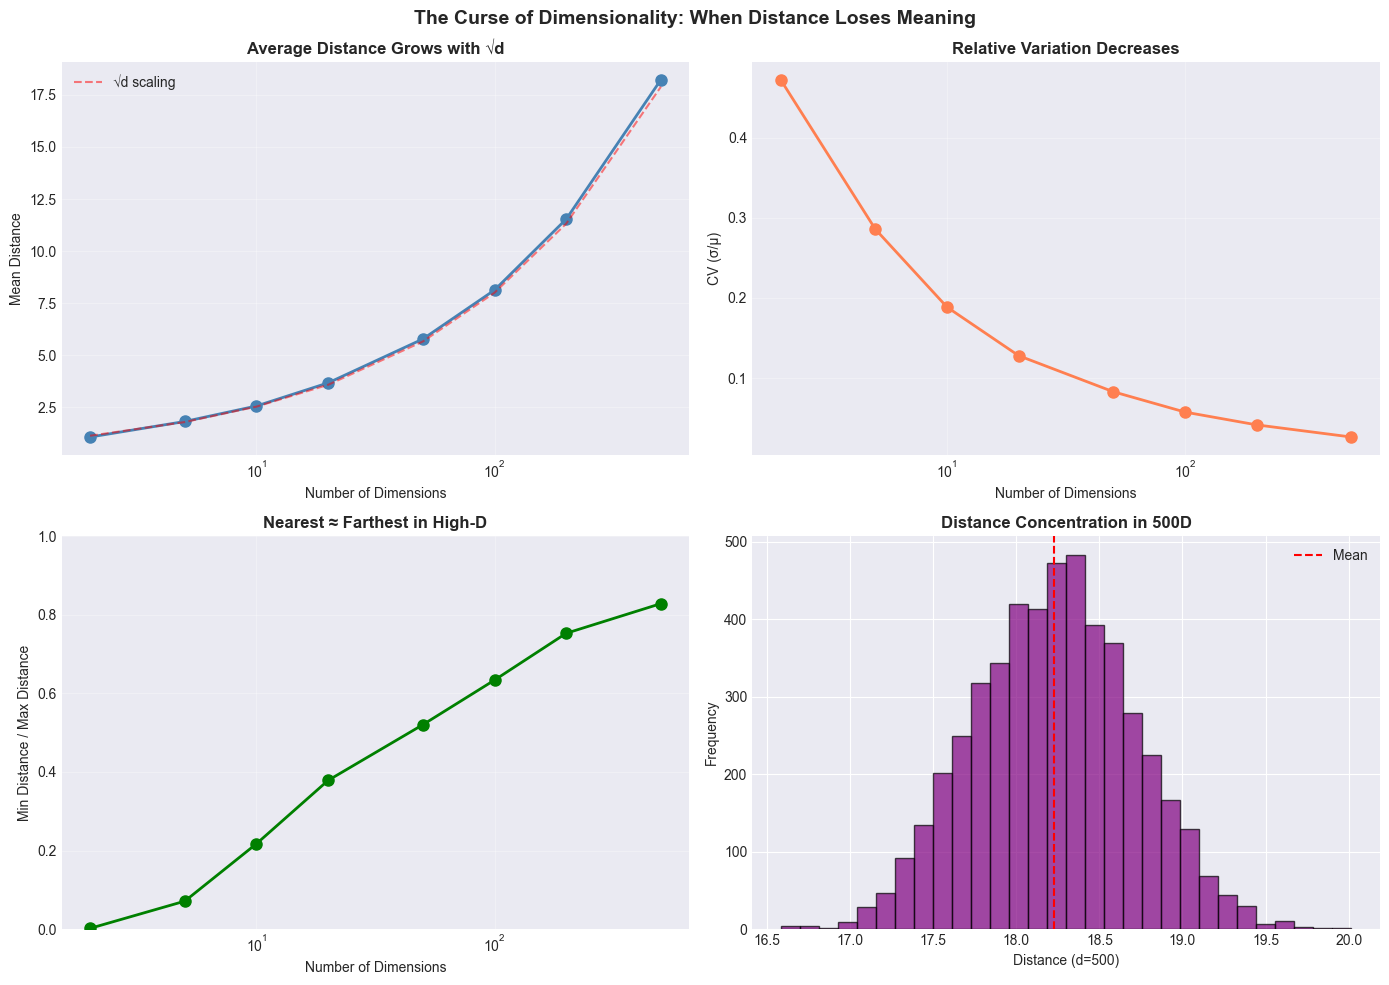

d=  2 | mean=1.069 | CV=0.472 | min/max=0.002
d=  5 | mean=1.817 | CV=0.286 | min/max=0.071
d= 10 | mean=2.561 | CV=0.189 | min/max=0.217
d= 20 | mean=3.670 | CV=0.128 | min/max=0.379
d= 50 | mean=5.776 | CV=0.083 | min/max=0.520
d=100 | mean=8.127 | CV=0.058 | min/max=0.634
d=200 | mean=11.532 | CV=0.042 | min/max=0.753
d=500 | mean=18.228 | CV=0.026 | min/max=0.828


In [15]:
from sklearn.metrics.pairwise import euclidean_distances
def demonstrate_curse_of_dimensionality():
    """
    Empirically demonstrate how distances lose meaning in high dimensions
    """
    # Test different dimensionalities
    dimensions_range = [2, 5, 10, 20, 50, 100, 200, 500]
    
    # Storage for results
    results = {
        'dims': dimensions_range,
        'mean_dist': [],
        'std_dist': [],
        'cv': [],  # Coefficient of variation
        'min_max_ratio': []
    }
    
    for d in dimensions_range:
        # Generate random data in d dimensions
        # 100 points uniformly distributed in unit hypercube
        np.random.seed(42)
        points = np.random.uniform(-1, 1, size=(100, d))
        
        # Calculate all pairwise distances
        distances = euclidean_distances(points)
        
        # Extract upper triangle (unique pairs only)
        upper_tri_indices = np.triu_indices(100, k=1)
        pairwise_distances = distances[upper_tri_indices]
        
        # Calculate statistics
        mean_d = pairwise_distances.mean()
        std_d = pairwise_distances.std()
        
        results['mean_dist'].append(mean_d)
        results['std_dist'].append(std_d)
        results['cv'].append(std_d / mean_d)  # Relative variability
        results['min_max_ratio'].append(
            pairwise_distances.min() / pairwise_distances.max()
        )
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Mean distance growth
    axes[0, 0].plot(results['dims'], results['mean_dist'], 
                    'o-', color='steelblue', linewidth=2, markersize=8)
    axes[0, 0].plot(results['dims'], np.sqrt(results['dims']) * 0.8, 
                    '--', color='red', alpha=0.5, label='√d scaling')
    axes[0, 0].set_xlabel('Number of Dimensions')
    axes[0, 0].set_ylabel('Mean Distance')
    axes[0, 0].set_title('Average Distance Grows with √d', fontweight='bold')
    axes[0, 0].set_xscale('log')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Coefficient of variation
    axes[0, 1].plot(results['dims'], results['cv'], 
                    'o-', color='coral', linewidth=2, markersize=8)
    axes[0, 1].set_xlabel('Number of Dimensions')
    axes[0, 1].set_ylabel('CV (σ/μ)')
    axes[0, 1].set_title('Relative Variation Decreases', fontweight='bold')
    axes[0, 1].set_xscale('log')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Min/Max ratio
    axes[1, 0].plot(results['dims'], results['min_max_ratio'], 
                    'o-', color='green', linewidth=2, markersize=8)
    axes[1, 0].set_xlabel('Number of Dimensions')
    axes[1, 0].set_ylabel('Min Distance / Max Distance')
    axes[1, 0].set_title('Nearest ≈ Farthest in High-D', fontweight='bold')
    axes[1, 0].set_xscale('log')
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Distance concentration
    axes[1, 1].hist(pairwise_distances, bins=30, alpha=0.7, 
                    color='purple', edgecolor='black')
#     axes[1, 1].set_xlabel(f'Distance (d={dimensions_range[-1]})')
    axes[1, 1].set_xlabel(f"Distance (d={results['dims'][-1]})")
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Distance Concentration in 500D', fontweight='bold')
    axes[1, 1].axvline(pairwise_distances.mean(), color='red', 
                       linestyle='--', label='Mean')
    axes[1, 1].legend()
    
    plt.suptitle('The Curse of Dimensionality: When Distance Loses Meaning', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    for d, mean, cv, mm in zip(results['dims'], results['mean_dist'], results['cv'], results['min_max_ratio']):
        print(f"d={d:>3} | mean={mean:.3f} | CV={cv:.3f} | min/max={mm:.3f}")
    
    return results

# Demonstrate the curse
curse_results = demonstrate_curse_of_dimensionality()

### **Critical Insights:**
- **Distance Growth**: Mean distance ∝ √d (square root of dimensions)
- **Variance Collapse**: Relative variation → 0 as d increases
- **Discrimination Loss**: min_dist/max_dist → 1 (all points equidistant!)
- **k-NN Breakdown**: When all points are equally far, k-NN becomes random

## Impact on Our Student Matching

### **Real-World Application:**
Let's see how dimensionality affects our actual student matching system

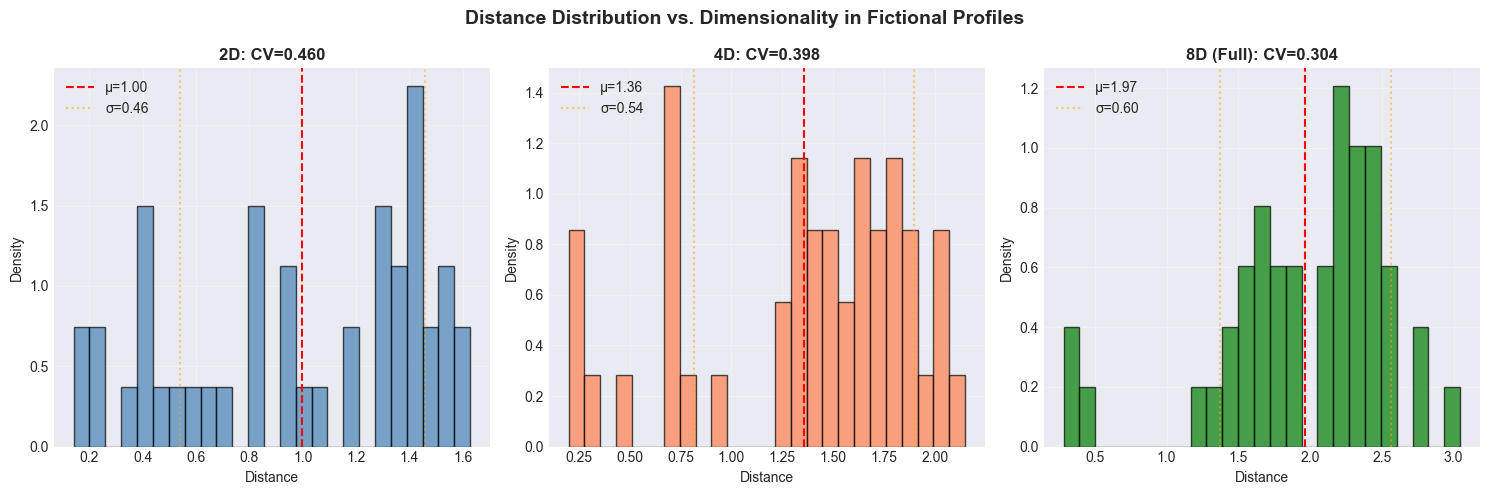

In [16]:
def analyze_student_distance_distribution():
    """
    Compare distance distributions using different numbers of features
    """
    # Define feature subsets of increasing size
    feature_sets = {
        '2D': dimensions[:2],
        '4D': dimensions[:4], 
        '8D (Full)': dimensions
    }
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Store statistics for comparison
    stats_comparison = []
    
    for idx, (name, features) in enumerate(feature_sets.items()):
        ax = axes[idx]
        
        # Calculate pairwise distances
        X = students[features].values
        distances = euclidean_distances(X)
        
        # Get upper triangle (unique pairs)
        upper_tri = distances[np.triu_indices(len(students), k=1)]
        
        # Plot distribution
        n, bins, patches = ax.hist(upper_tri, bins=25, alpha=0.7, 
                                   color=['steelblue', 'coral', 'green'][idx],
                                   edgecolor='black', density=True)
        
        # Add statistics
        mean_dist = upper_tri.mean()
        std_dist = upper_tri.std()
        cv = std_dist / mean_dist
        
        ax.axvline(mean_dist, color='red', linestyle='--', 
                  label=f'μ={mean_dist:.2f}')
        ax.axvline(mean_dist - std_dist, color='orange', linestyle=':', 
                  alpha=0.5)
        ax.axvline(mean_dist + std_dist, color='orange', linestyle=':', 
                  alpha=0.5, label=f'σ={std_dist:.2f}')
        
        # Labels
        ax.set_xlabel('Distance')
        ax.set_ylabel('Density')
        ax.set_title(f'{name}: CV={cv:.3f}', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Store stats
        stats_comparison.append({
            'dimensions': name,
            'n_features': len(features),
            'mean': mean_dist,
            'std': std_dist,
            'cv': cv,
            'min': upper_tri.min(),
            'max': upper_tri.max(),
            'range_ratio': upper_tri.min() / upper_tri.max()
        })
    
    plt.suptitle('Distance Distribution vs. Dimensionality in Fictional Profiles', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame(stats_comparison)

# Analyze the fictional profiles
distance_stats = analyze_student_distance_distribution()

### 💡 **Practical Implications:**
- **2D view**: Shows two of eight features; omitted features may matter
- **4D view**: Balanced - reasonable discrimination with key features
- **8D (full)**: Uses all features; inspect whether distances still distinguish candidates
- **Solution**: Feature selection or dimensionality reduction may improve matching!

# Part 5: Distance Metrics - The Heart of K-NN

## Different Ways to Measure "Nearness"

### **Key Concept:**
In K-NN, the distance metric IS the model! Different metrics find different neighbors.

###  **Common Distance Metrics:**
- **Euclidean**: Straight-line distance (most common)
- **Manhattan**: City-block distance (sum of absolute differences)
- **Cosine**: Angle between vectors (direction matters, not magnitude)
- **Chebyshev**: Maximum coordinate difference (chess king moves)

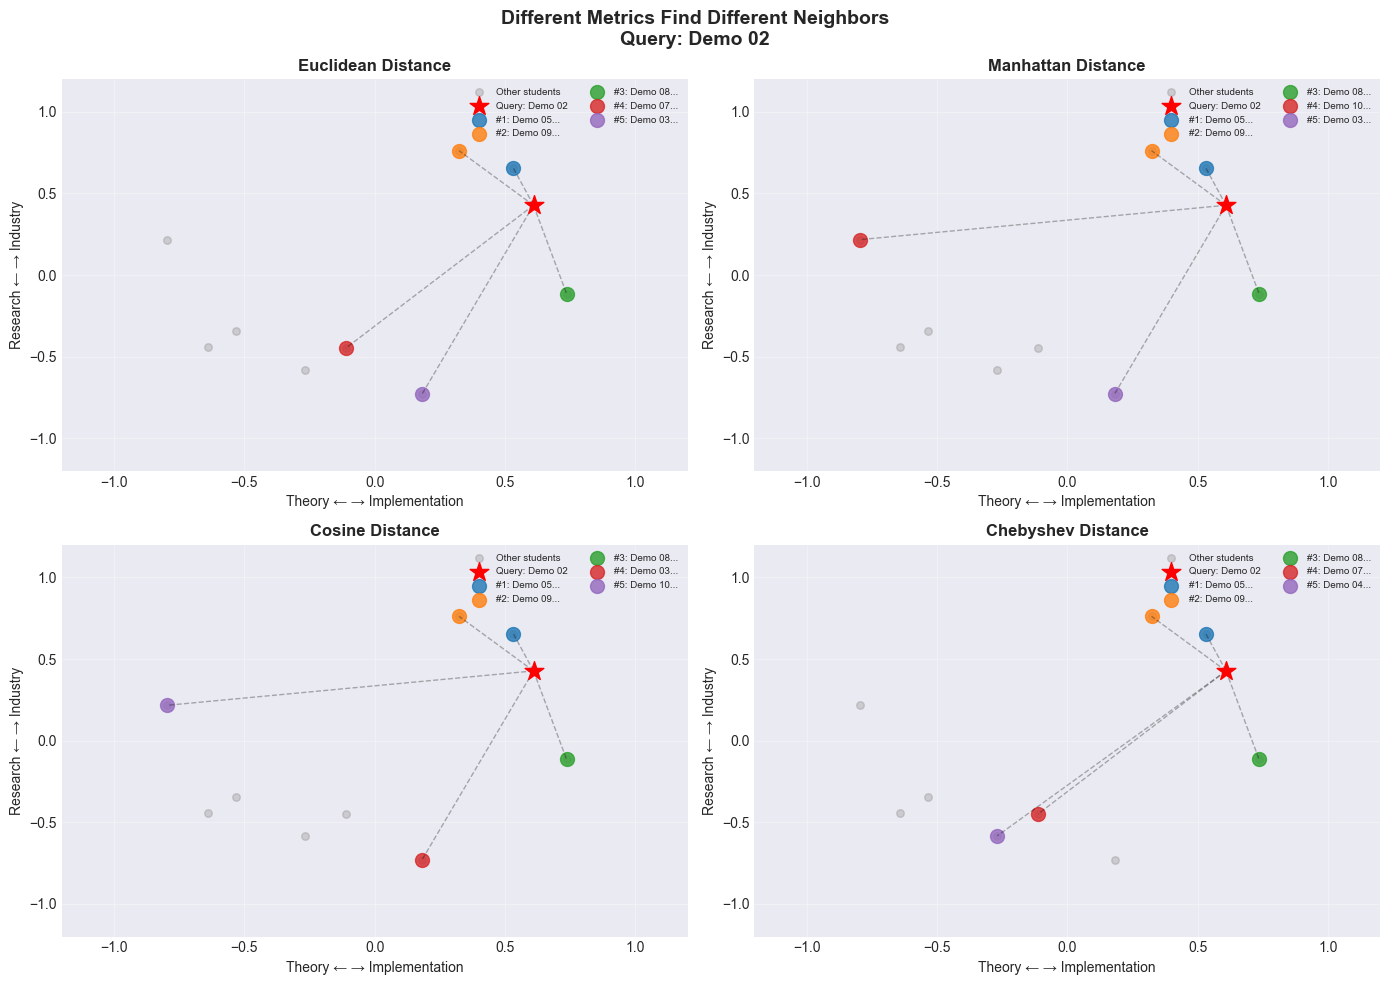

In [17]:
def compare_distance_metrics(query_idx = 0):
    """
    Compare how different metrics define "nearest neighbors"
    """
    # Select a query student
    query_student = students.iloc[query_idx]
    query_plot = plot_students.iloc[query_idx]
    
    # Prepare feature matrix
#     X = students[dimensions].values
    x_dim = 'theory_implementation'
    y_dim = 'research_industry'
    X = students[[x_dim, y_dim]].values
    query_vector = query_student[[x_dim, y_dim]].values.reshape(1, -1)
#     query_vector = query_student[dimensions].values.reshape(1, -1)
    
    # Calculate distances using different metrics
    from sklearn.metrics import pairwise_distances
    
    metrics_to_test = {
        'Euclidean': 'euclidean',
        'Manhattan': 'manhattan',
        'Cosine': 'cosine',
        'Chebyshev': 'chebyshev'
    }
    
    # Store results
    neighbor_comparison = {}
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, (metric_name, metric) in enumerate(metrics_to_test.items()):
        ax = axes[idx]
        
        # Calculate distances
        distances = pairwise_distances(query_vector, X, metric=metric)[0]
        
        # Exclude self (set distance to infinity)
        distances[query_idx] = np.inf
        
        # Find top 5 neighbors
        top_5_indices = np.argsort(distances)[:5]
        neighbor_comparison[metric_name] = top_5_indices
        
        # Visualize in 2D projection
        # Plot all students
        ax.scatter(plot_students['theory_implementation'], 
                  plot_students['research_industry'],
                  alpha=0.3, s=30, color='gray', label='Other students')
        
        # Highlight query student
        ax.scatter(query_plot['theory_implementation'],
                  query_plot['research_industry'],
                  s=200, color='red', marker='*', 
                  label=f"Query: {query_student['name']}", zorder=5)
        
        # Highlight and connect neighbors
        for rank, neighbor_idx in enumerate(top_5_indices):
            neighbor = plot_students.iloc[neighbor_idx]
            
            # Plot neighbor
            ax.scatter(neighbor['theory_implementation'],
                      neighbor['research_industry'],
                      s=100, marker='o', alpha=0.8,
                      label=f"#{rank+1}: {neighbor['name'][:12]}...")
            
            # Draw connection line
            ax.plot([query_plot['theory_implementation'], 
                    neighbor['theory_implementation']],
                   [query_plot['research_industry'], 
                    neighbor['research_industry']],
                   'k--', alpha=0.3, linewidth=1)
        
        # Formatting
        ax.set_xlabel('Theory ← → Implementation')
        ax.set_ylabel('Research ← → Industry')
        ax.set_title(f'{metric_name} Distance', fontsize=12, fontweight='bold')
        ax.legend(fontsize=7, loc='best', ncol=2)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.2, 1.2)
    
    plt.suptitle(f'Different Metrics Find Different Neighbors\nQuery: {query_student["name"]}', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return neighbor_comparison

# Compare metrics
neighbor_comparison = compare_distance_metrics(1)


### **Metric Comparison Results:**
- **Euclidean**: Balanced, considers all dimensions equally
- **Manhattan**: Favors neighbors close on individual dimensions
- **Cosine**: Finds students with similar preference patterns (ignores magnitude)
- **Chebyshev**: Focuses on the largest single difference

## Mathematical Formulations

### **Distance Formulas:**

**Euclidean Distance:**
$$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

**Manhattan Distance:**
$$d(x, y) = \sum_{i=1}^{n} |x_i - y_i|$$

**Cosine Similarity:**
$$\cos(\theta) = \frac{x \cdot y}{||x|| \cdot ||y||} = \frac{\sum_{i=1}^{n} x_i y_i}{\sqrt{\sum_{i=1}^{n} x_i^2} \cdot \sqrt{\sum_{i=1}^{n} y_i^2}}$$

**Chebyshev Distance:**
$$d(x, y) = \max_i |x_i - y_i|$$

# Part 6: Metric Learning - Finding the Right Distance

## Learning What "Similar" Means

### **The Challenge:**
- Not all features are equally important for matching
- Some dimensions might be more relevant for team compatibility
- Can we learn which features matter from user feedback?

In [18]:
import pandas as pd
from textwrap import shorten

def show_students_table(df, idxs, dims, preview_key='project_ideas', width=80):
    rows = []
    for i in idxs:
        s = df.iloc[i]
        row = {
            'idx': i,
            'name': s.get('name',''),
            'interest': s.get('main_interest',''),
        }
        row.update({ d: round(float(s[d]), 2) for d in dims })
        if isinstance(s.get('original_responses'), dict) and preview_key in s['original_responses']:
            row['preview'] = shorten(str(s['original_responses'][preview_key]), width=width, placeholder='…')
        else:
            row['preview'] = ''
        rows.append(row)
    display(pd.DataFrame(rows))

In [19]:
show_students_table(students, [0,1,2,3,5], dimensions, preview_key='project_approach', width=96)

,idx,name,interest,theory_implementation,research_industry,structured_exploratory,solo_collaborative,depth_breadth,plan_iterate,data_model,foundational_applied,preview
0,0,Demo 01,nlp,-0.65,-0.45,0.15,0.75,-0.35,-0.55,0.25,-0.15,Start with a written plan and test a small bas...
1,1,Demo 02,computer_vision,0.65,0.45,-0.55,0.35,0.15,0.65,-0.25,0.55,"Build a small prototype, then revise it after ..."
2,2,Demo 03,robotics,0.15,-0.75,0.65,-0.65,0.75,-0.15,0.55,-0.75,Start with a written plan and test a small bas...
3,3,Demo 04,healthcare,-0.25,-0.55,-0.35,0.55,0.45,0.15,-0.65,0.25,"Build a small prototype, then revise it after ..."
4,5,Demo 06,nlp,-0.55,-0.35,0.25,0.65,-0.45,-0.65,0.15,-0.25,Start with a written plan and test a small bas...


In [20]:
import numpy as np

class SimpleMetricLearner:
    """
    Learn per-feature weights from multiple triplets.
    Each triplet: anchor should be closer to positive than negative.
    """
    def __init__(self, n_features, learning_rate=0.1):
        self.weights = np.ones(n_features, dtype=float)
        self.lr = float(learning_rate)
        self.n_features = n_features

    def learn_from_triplet(self, anchor, positive, negative):
        # Feature-wise absolute differences
        pos_diff = np.abs(anchor - positive)
        neg_diff = np.abs(anchor - negative)
        # Multiplicative update: reinforce features where pos is closer than neg
        inc = (pos_diff < neg_diff)
        dec = (pos_diff > neg_diff)
        self.weights[inc] *= (1 + self.lr)
        self.weights[dec] *= (1 - self.lr)
        # Keep average weight ~ 1
        self.weights /= self.weights.mean()

    def fit_triplets(self, triplets, n_iters=10, verbose=False):
        """
        triplets: list of (anchor_vec, positive_vec, negative_vec)
        """
        for it in range(n_iters):
            for a, p, n in triplets:
                self.learn_from_triplet(a, p, n)
            if verbose and (it==0 or (it+1)%5==0 or it==n_iters-1):
                print(f"iter {it+1}: weights min={self.weights.min():.3f} max={self.weights.max():.3f}")
        return self

    def weighted_distance(self, x, y):
        # Weighted Euclidean
        return np.sqrt(((self.weights * (x - y)**2)).sum())

In [21]:
def build_triplets(students, dims, anchor_sets):
    """
    anchor_sets: list of dicts like
      {'anchor': idx_a, 'positive': idx_p, 'negative': idx_n}
    Returns list of (a_vec, p_vec, n_vec) numpy arrays.
    """
    triplets = []
    for t in anchor_sets:
        a = students.iloc[t['anchor']][dims].values.astype(float)
        p = students.iloc[t['positive']][dims].values.astype(float)
        n = students.iloc[t['negative']][dims].values.astype(float)
        triplets.append((a, p, n))
    return triplets

In [22]:
# Illustrative preference feedback for the fictional profiles (zero-based indices).
anchor_sets = [
    {'anchor': 0, 'positive': 5, 'negative': 2},
    {'anchor': 1, 'positive': 4, 'negative': 2},
    {'anchor': 3, 'positive': 6, 'negative': 2},
]
triplets = build_triplets(students, dimensions, anchor_sets)


In [23]:
def eval_triplets(triplets, weights, label=""):
    """
    For each triplet, print distances d(anchor,pos) and d(anchor,neg).
    Report if the constraint is satisfied (pos < neg).
    """
    sat = 0
    for i, (a, p, n) in enumerate(triplets, 1):
        w = np.asarray(weights, dtype=float)
        d_ap = np.sqrt(((w * (a - p)**2)).sum())
        d_an = np.sqrt(((w * (a - n)**2)).sum())
        ok = d_ap < d_an
        sat += int(ok)
        print(f"[{label}] Triplet {i}: d(a,p)={d_ap:.3f}  d(a,n)={d_an:.3f}  -> {'OK' if ok else 'VIOLATION'} (margin={d_an-d_ap:+.3f})")
    print(f"[{label}] Satisfied: {sat}/{len(triplets)} ({100*sat/len(triplets):.1f}%)\n")

In [24]:
#  Evaluate with equal weights (baseline)
w0 = np.ones(len(dimensions))
eval_triplets(triplets, w0, label="Before")

[Before] Triplet 1: d(a,p)=0.283  d(a,n)=2.182  -> OK (margin=+1.899)
[Before] Triplet 2: d(a,p)=0.412  d(a,n)=2.731  -> OK (margin=+2.319)
[Before] Triplet 3: d(a,p)=0.283  d(a,n)=2.293  -> OK (margin=+2.011)
[Before] Satisfied: 3/3 (100.0%)



In [25]:
# Learn metric across all triplets
learner = SimpleMetricLearner(n_features=len(dimensions), learning_rate=0.1)
learner.fit_triplets(triplets, n_iters=20, verbose=True)

# Evaluate after learning
eval_triplets(triplets, learner.weights, label="After")

iter 1: weights min=1.000 max=1.000
iter 5: weights min=1.000 max=1.000
iter 10: weights min=1.000 max=1.000
iter 15: weights min=1.000 max=1.000
iter 20: weights min=1.000 max=1.000
[After] Triplet 1: d(a,p)=0.283  d(a,n)=2.182  -> OK (margin=+1.899)
[After] Triplet 2: d(a,p)=0.412  d(a,n)=2.731  -> OK (margin=+2.319)
[After] Triplet 3: d(a,p)=0.283  d(a,n)=2.293  -> OK (margin=+2.011)
[After] Satisfied: 3/3 (100.0%)



In [26]:
# Show weight changes
pd.DataFrame({
    'dimension': dimensions,
    'weight_before': 1.0,
    'weight_after': learner.weights.round(3),
    'change': (learner.weights - 1.0).round(3),
})

,dimension,weight_before,weight_after,change
0,theory_implementation,1.0,1.0,0.0
1,research_industry,1.0,1.0,0.0
2,structured_exploratory,1.0,1.0,0.0
3,solo_collaborative,1.0,1.0,0.0
4,depth_breadth,1.0,1.0,0.0
5,plan_iterate,1.0,1.0,0.0
6,data_model,1.0,1.0,0.0
7,foundational_applied,1.0,1.0,0.0



### **Metric Learning Insights:**
- **Adaptive weights**: Learn which dimensions matter for YOUR definition of similarity
- **User feedback integration**: Improves with more examples
- **Domain-specific metrics**: Better than generic distance measures
- **Practical application**: Could learn from successful past teams


## Domain-Specific Distance: Complementary Skills

### **Smart Matching Strategy:**
Sometimes we want teammates who are:
- **Similar** in work style (for smooth collaboration)
- **Different** in skills (for comprehensive coverage)


In [27]:
import numpy as np
import matplotlib.pyplot as plt

def complementary_distance(student1, student2, complement_dims, similar_dims):
    """
    Simple combined distance (lower = better match).
    - Similarity on similar_dims: sum of squared diffs
    - Complementarity on complement_dims: (2 - |diff|)^2
      Assumes features in [-1, 1] so max |diff| is 2.
    """
    similarity_score = 0.0
    for dim in similar_dims:
        diff = float(student1[dim] - student2[dim])
        similarity_score += diff**2

    complementarity_score = 0.0
    for dim in complement_dims:
        diff = abs(float(student1[dim] - student2[dim]))
        complementarity_score += (2.0 - diff)**2  # max diff assumed 2

    total_distance = np.sqrt(0.5 * similarity_score + 0.5 * complementarity_score)
    return total_distance

In [28]:
def find_complementary_team(
    students,
    similar_dims=('solo_collaborative', 'plan_iterate'),
    complement_dims=('theory_implementation', 'data_model'),
    query_idx=None,
    n_matches=3
):
    """
    Build a balanced team with complementary skills (simple metric, clear visuals).
    """
    # 1) Choose query
    if query_idx is None:
        seekers = students[students['team_status'].str.contains('seeking')]
        if len(seekers) == 0:
            raise ValueError("No 'seeking' students found. Provide query_idx explicitly.")
        query_student = seekers.iloc[0]
        query_idx = query_student.name
    else:
        query_student = students.iloc[query_idx]

    # 2) Score candidates (exclude self and solo)
    distances = []
    for idx, s in students.iterrows():
        if idx == query_idx or str(s.get('team_status','')) == 'solo':
            continue
        d = complementary_distance(query_student, s, complement_dims, similar_dims)
        distances.append((idx, d, s))
    distances.sort(key=lambda t: t[1])

    # Limit matches
    n_matches = min(n_matches, len(distances))
    top = distances[:n_matches]

    # -------- Visualization (clear colors/legends) --------
    COLOR_QUERY = '#d62728'     # red for query emphasis
    DIM_COLORS = ['#2ca02c', '#9467bd', '#1f77b4', '#ff7f0e']  # cycle if >2 dims

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(
        f"Complementary Teaming • Query: {query_student.get('name','(unknown)')}",
        fontsize=14, fontweight='bold'
    )

    # Left: Complementary skills (want diversity)
    ax1 = axes[0]
    member_labels = [f"Query\n{query_student.get('name','')[:14]}"] + \
                    [f"Match {i+1}\n{top[i][2].get('name','')[:14]}" for i in range(n_matches)]
    x = np.arange(len(member_labels))
    width = 0.35

    # Per-dimension series (aligned to members)
    bars_per_dim = []
    for i, dim in enumerate(complement_dims):
        series = [float(query_student[dim])] + [float(top[j][2][dim]) for j in range(n_matches)]
        offset = (i - (len(complement_dims) - 1)/2.0) * width
        b = ax1.bar(x + offset, series, width,
                    label=dim.replace('_', ' ').title(),
                    color=DIM_COLORS[i % len(DIM_COLORS)],
                    alpha=0.85, edgecolor='white', linewidth=0.5)
        # Outline the query in red; keep dimension colors consistent with the legend
        b[0].set_edgecolor(COLOR_QUERY)
        b[0].set_linewidth(2)
        bars_per_dim.append(b)

        # Annotate values
        for rect in b:
            h = rect.get_height()
            ax1.text(rect.get_x() + rect.get_width()/2, h,
                     f"{h:+.2f}", ha='center', va='bottom', fontsize=9, color='#333')

    ax1.set_title("Complementary Skills (diversity desired)", fontweight='bold')
    ax1.set_ylabel("Feature Value")
    ax1.set_xticks(x)
    ax1.set_xticklabels(member_labels, fontsize=9)
    ax1.axhline(0, color='#999', linewidth=0.8)
    ax1.grid(True, alpha=0.25, axis='y')
    ax1.legend(title="Complement Dimensions", frameon=True, fontsize=9)

    # Right: Work-style alignment (want similarity)
    ax2 = axes[1]
    for dim in similar_dims:
        y = [float(query_student[dim])] + [float(top[i][2][dim]) for i in range(n_matches)]
        xs = list(range(len(y)))
        line, = ax2.plot(xs, y, 'o-', linewidth=2, markersize=7, alpha=0.9,
                         label=dim.replace('_', ' ').title())
        # Emphasize query point in red
        ax2.plot([0], [y[0]], marker='o', markersize=8, color=COLOR_QUERY)

    ax2.set_title("Work-Style Alignment (similarity desired)", fontweight='bold')
    ax2.set_xlabel("Team Members (0 = Query)")
    ax2.set_ylabel("Feature Value")
    ax2.set_xticks(range(n_matches + 1))
    ax2.set_xticklabels(['Query'] + [f"Match {i+1}" for i in range(n_matches)])
    ax2.grid(True, alpha=0.25)
    ax2.legend(title="Similar Dimensions", frameon=True, fontsize=9)

    plt.tight_layout()
    plt.show()

    # Print concise ranked list
    print("Top matches (lower = better under simple metric):")
    for rank, (idx, d, s) in enumerate(top, 1):
        print(f"{rank}. idx={idx:>2}  {s.get('name',''):20s}  score={d:.3f}  interest={s.get('main_interest','')}")

    return query_student, top

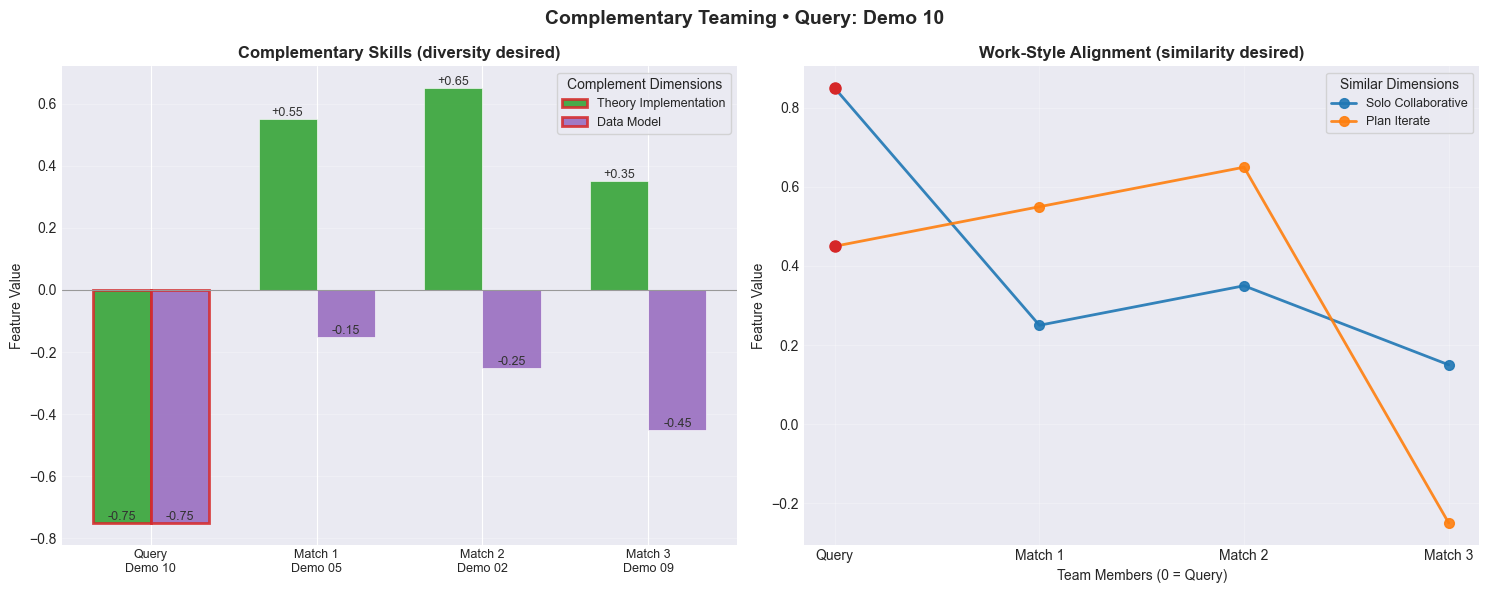

Top matches (lower = better under simple metric):
1. idx= 4  Demo 05               score=1.187  interest=cybersecurity
2. idx= 1  Demo 02               score=1.204  interest=computer_vision
3. idx= 8  Demo 09               score=1.530  interest=general


In [29]:
similar_dims = ['solo_collaborative', 'plan_iterate']        # want similar
complement_dims = ['theory_implementation', 'data_model']    # want diverse

query, top_matches = find_complementary_team(
    students,
    similar_dims=similar_dims,
    complement_dims=complement_dims,
    query_idx=9,     # or None to auto-pick first 'seeking'
    n_matches=3
)

###  **Smart Matching Insights:**
- **Skill diversity**: Team members cover different strengths
- **Work style alignment**: Similar collaboration preferences reduce friction
- **Balanced teams**: Neither too similar (groupthink) nor too different (conflict)
- **Customizable strategy**: Adjust weights based on project needs

# Key Takeaways

## What We've Learned

1. **K-NN is beautifully simple**: No training, just remember and compare
2. **Distance metrics matter**: Different metrics find different neighbors
3. **Curse of dimensionality is real**: More features ≠ better matching
4. **Fairness requires intentional design**: Algorithms can amplify biases
5. **Domain knowledge is crucial**: Generic similarity might not match your needs

## When to Use k-NN

### **Great for:**
- Non-linear patterns
- Local structure varies across space
- Need interpretable predictions
- Small to medium datasets
- When you have good distance metrics

### **Avoid when:**
- Very high dimensions (>50)
- Need fast predictions at scale
- Data has clear global patterns
- Training data is extremely large

Remember: The algorithm is only as good as the features and metrics we choose!

# End of Lecture 2

Thank you for your engaged participation! 🎉

Try different features and explain how your choice changes the matches.